# Regressão Linear
#### Preditando a popularidade de um filme com base no ano de lançamento, nota média e contagem de votos
#### Integrantes
- Gabriel Almeida Mota Bomfim
- Pedro Caldas de Souze Lucas Marques
- Carlos Henrique Fontes Cabral
#### Fonte dos dados:
- https://www.kaggle.com/datasets/siddharthbhakta/tmdb-top-10000-movies-updated-2026
#### Objetivo
Preditar a popularidade do filme
#### Atributo-Alvo
- Feature popularity
#### Atributos preditivos
- Ano
- vote_average
- vote_count

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

movies = pd.read_csv("moviesTMBD.csv")

# Compressão dos dados

In [3]:
movies.head(10)

,Unnamed: 0,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
0,0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929
3,3,687163,Project Hail Mary,422.0199,False,en,Science teacher Ryland Grace wakes up on a spa...,2026-03-15,8.621,3950
4,4,240,The Godfather Part II,27.6763,False,en,In the continuing saga of the Corleone crime f...,1974-12-20,8.571,13901
5,5,424,Schindler's List,35.8510,False,en,The true story of how businessman Oskar Schind...,1993-12-15,8.569,17447
6,6,389,12 Angry Men,22.8937,False,en,The defense and the prosecution have rested an...,1957-04-10,8.600,9977
7,7,1330021,Remarkably Bright Creatures,96.5828,False,en,Through unlikely bonds formed during night shi...,2026-05-07,8.546,393
8,8,129,Spirited Away,32.2851,False,ja,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,8.534,18302
9,9,155,The Dark Knight,45.5176,False,en,Batman raises the stakes in his war on crime. ...,2008-07-16,8.530,35750


#### Verificando dados ausentes e duplicações
- Procurando nas colunas do dataset com valores reais em busca de valores NaN

In [4]:
movies.info()

print('-----------------------------')
print('Verificando valores NaN')
print(movies.isna().sum())

qtd_titulos_duplicados = movies.duplicated(subset=['title']).sum()
qtd_overview_duplicadas = movies.duplicated(subset=['overview']).sum()

print("-----------------------------")
print("Verificando duplicações")
print(f"Títulos duplicados: {qtd_titulos_duplicados}")
print(f"Overview duplicadas: {qtd_overview_duplicadas}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9980 non-null   int64  
 1   id                 9980 non-null   int64  
 2   title              9980 non-null   object 
 3   popularity         9980 non-null   float64
 4   adult              9980 non-null   bool   
 5   original_language  9980 non-null   object 
 6   overview           9978 non-null   object 
 7   release_date       9978 non-null   object 
 8   vote_average       9980 non-null   float64
 9   vote_count         9980 non-null   int64  
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 711.6+ KB
-----------------------------
Verificando valores NaN
Unnamed: 0           0
id                   0
title                0
popularity           0
adult                0
original_language    0
overview             2
release_date         2
vote_a

#### Limpando o dataset
- Remoção de duplicatas de título e overview
- Remoção de overview com valores NaN

In [5]:
movies_filtrado = movies.dropna(subset=['overview', 'release_date'])
movies_filtrado = movies_filtrado.drop_duplicates(subset=['title'], keep=False)
movies_filtrado = movies_filtrado.drop_duplicates(subset=['overview'], keep=False)

#### Adicionando features
- Alterando a coluna 'release_date' para a idade do filme (primeiro tivemos que converter o tipo da coluna para datetime)

In [6]:
# Convertendo para datetime
movies_filtrado = movies_filtrado.copy()

movies_filtrado['release_date'] = pd.to_datetime(
    movies_filtrado['release_date'],
)

# Idade do filme é baseada na conta: idade = (dia_atual - dia_do_filme) / 365.25 
movies_filtrado['movie_age']=(
    pd.Timestamp.today()-movies_filtrado['release_date']
).dt.days /365.25

# Removendo a coluna antida 'release_date'
movies_filtrado = movies_filtrado.drop('release_date', axis=1)

#### Verificando Outliers
1) Scatter plot da relação de 'populariry' e 'vote_counts'
- Essa relação nos mostra os outliers existentes na coluna 'popularity'

<Axes: xlabel='vote_count', ylabel='popularity'>

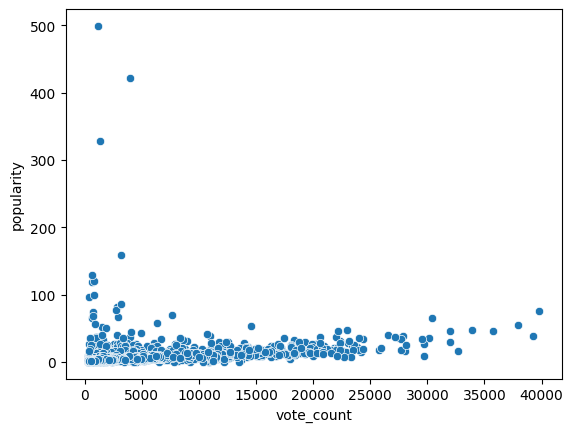

In [7]:
sns.scatterplot(data=movies_filtrado,
                x='vote_count',
                y='popularity')

#### Tratando Outliers
- Transformando os dados para uma escala logarítmica

<Axes: xlabel='log_vote_count', ylabel='log_popularity'>

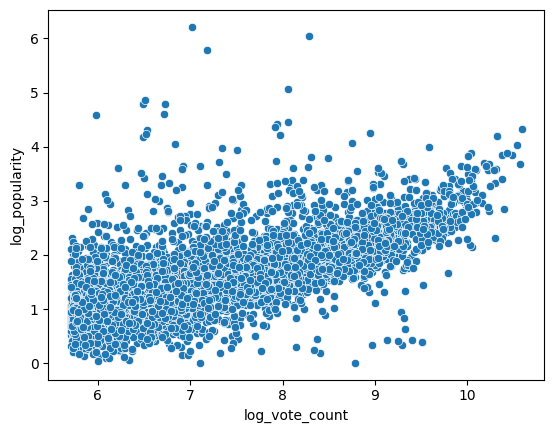

In [8]:
movies_filtrado['log_popularity'] = np.log1p(movies_filtrado['popularity'])
movies_filtrado['log_vote_count'] = np.log1p(movies_filtrado['vote_count'])
sns.scatterplot(data=movies_filtrado,
                x='log_vote_count',
                y='log_popularity')

## Divisão dos dados treino e test

In [9]:
from sklearn.model_selection import train_test_split

# Definição das variáveis
X = movies_filtrado[['log_vote_count','vote_average','movie_age']]
y = movies_filtrado['log_popularity']

# Divisão do conjunto de dados em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### Aplicando Regressão Linear nos dados
- Objetivo: queremos preditar a variável 'popularity'
- Utilizamos: vote_count, vote_average e movie_age

In [14]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()

model_LR.fit(X_train, y_train)

fitted_LR = model_LR.predict(X_test)

# Residuals são os erros cometidos pelo modelo a cada observação
residuals_LR = y_test-fitted_LR

#### Aplicando Decision Tree

In [20]:
from sklearn.tree import DecisionTreeRegressor

model_DT = DecisionTreeRegressor(max_depth=5)

model_DT.fit(X_train, y_train)

fitted_DT = model_DT.predict(X_test)
residuals_DT = y_test-fitted_DT

#### Aplicando Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

model_RF = RandomForestRegressor(max_depth=4, random_state=0)
model_RF.fit(X_train,y_train)

fitted_RF = model_RF.predict(X_test)
residuals_RF = y_test-fitted_RF

### Métricas de Avaliação de cada modelo

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae_LR = mean_absolute_error(y_test, fitted_LR)
mse_LR = mean_squared_error(y_test, fitted_LR)
rmse_LR = np.sqrt(mse_LR) 

print("======= Resultados Regressão Linear =========")
print(f"R2 Score: {r2_score(y_test, fitted_LR):.4f}")
print(f"MAE: {mae_LR:.4f}")
print(f"MSE: {mse_LR:.4f}")
print(f"RMSE: {rmse_LR:.4f}")

print("======= Resultados Decision Tree =========")
mae_DT = mean_absolute_error(y_test, fitted_DT)
mse_DT = mean_squared_error(y_test, fitted_DT)
rmse_DT = np.sqrt(mse_DT) 

print(f"R2 Score: {r2_score(y_test, fitted_DT):.4f}")
print(f"MAE: {mae_DT:.4f}")
print(f"MSE: {mse_DT:.4f}")
print(f"RMSE: {rmse_DT:.4f}")

print("======== Resultados Random Forest ===========")
mae_RF = mean_absolute_error(y_test, fitted_RF)
mse_RF = mean_squared_error(y_test, fitted_RF)
rmse_RF = np.sqrt(mse_RF)

print(f"R2 Score: {r2_score(y_test, fitted_RF):.4f}")
print(f"MAE: {mae_RF:.4f}")
print(f"MSE: {mse_RF:.4f}")
print(f"RMSE: {rmse_RF:.4f}")
print("=============================================")

======= Resultados Regressão Linear =========
R2 Score: 0.5924
MAE: 0.2762
MSE: 0.1506
RMSE: 0.3880
======= Resultados Decision Tree =========
R2 Score: 0.6676
MAE: 0.2534
MSE: 0.1228
RMSE: 0.3504
======== Resultados Random Forest ===========
R2 Score: 0.6929
MAE: 0.2486
MSE: 0.1134
RMSE: 0.3368


#### Plotagem da relação dos acertos e erros Regressão Linear
- Quanto mais próximo da linha vermelha está um círculo, quer dizer que a previsão foi mais próxima do resultado real
- Quanto mais afastada, mais longe a previsão foi do resultado real

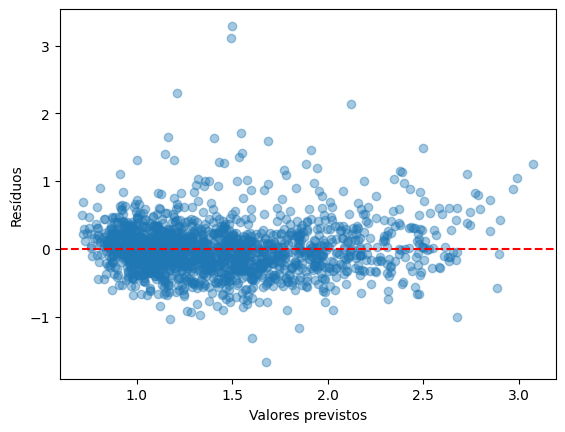

In [23]:
plt.scatter(fitted_LR, residuals_LR, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.show()

### Plotagem da relação dos acertos e erros Decision Tree

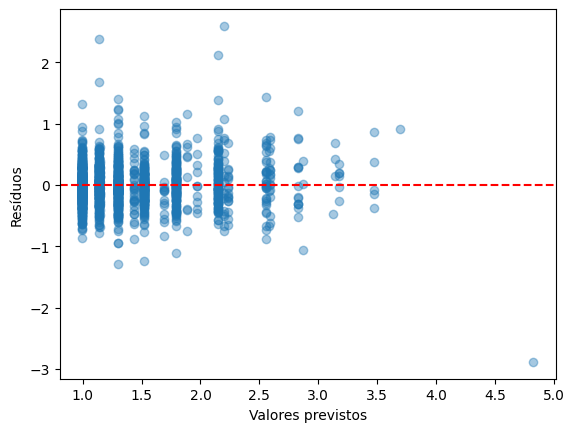

In [24]:
plt.scatter(fitted_DT, residuals_DT, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.show()

#### Plotagem da relação dos acertos e erros Random Forest
- Quanto mais próximo da linha vermelha está um círculo, quer dizer que a previsão foi mais próxima do resultado real
- Quanto mais afastada, mais longe a previsão foi do resultado real

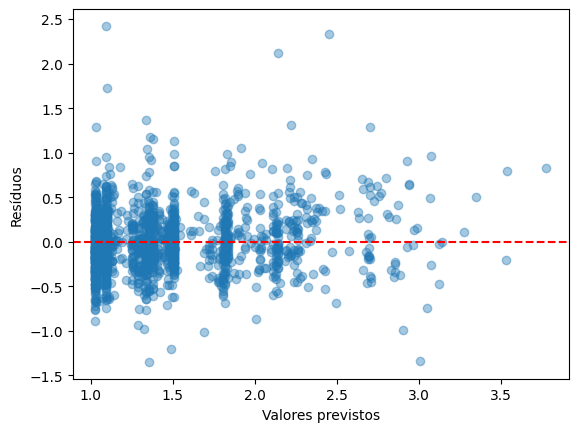

In [25]:
plt.scatter(fitted_RF, residuals_RF, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.show()